In [2]:
# 03 Weather Data Integration
#This notebook validates weather data availability for the project and prepares hourly Auckland weather variables for integration with GTFS transport delay data. This belongs to Layer 1 and Layer 2 of the system architecture only.

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PROJECT_ROOT

WindowsPath('d:/Yoobee/Term 3/Capstone/ai-dss-auckland-public-transport')

Meteostat was installed in the capstone-gtfs environment using pip.

In [4]:
from meteostat import Point, Hourly
from datetime import datetime

print("Meteostat import successful")

Meteostat import successful


In [5]:
import numpy
import meteostat

print(numpy.__version__)
print(meteostat.__version__)

1.26.4
1.6.7


In [6]:
from meteostat import Hourly

Hourly.clear_cache()

print("Meteostat cache cleared")

Meteostat cache cleared


In [7]:
from meteostat import Hourly

print(Hourly.cache_dir)

C:\Users\DTMAR\.meteostat\cache


In [8]:
import shutil
from meteostat import Hourly

cache_dir = Hourly.cache_dir
print("Deleting:", cache_dir)

shutil.rmtree(cache_dir, ignore_errors=True)

print("Meteostat cache folder deleted")

Deleting: C:\Users\DTMAR\.meteostat\cache
Meteostat cache folder deleted


In [9]:
from meteostat import Point, Hourly
from datetime import datetime

auckland = Point(-36.8485, 174.7633)

start = datetime(2024, 1, 1)
end = datetime(2024, 1, 3)

weather = Hourly(auckland, start, end)
weather_df = weather.fetch()

print("Shape:", weather_df.shape)
display(weather_df.head())

Shape: (49, 11)


,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2024-01-01 00:00:00,19.0,10.3,57.0,0.0,NaN,217.0,29.9,NaN,1020.0,NaN,3.0
2024-01-01 01:00:00,19.1,10.1,56.0,0.0,NaN,220.0,28.4,NaN,1020.1,NaN,3.0
2024-01-01 02:00:00,19.0,10.0,56.0,0.0,NaN,217.0,25.9,NaN,1020.0,NaN,3.0
2024-01-01 03:00:00,18.9,9.9,56.0,0.0,NaN,215.0,24.5,NaN,1020.0,NaN,3.0
2024-01-01 04:00:00,18.7,9.5,55.0,0.0,NaN,210.0,24.1,NaN,1019.9,NaN,3.0


In [ ]:
#Inspect missing values
weather_df.isna().sum()

temp     0
dwpt     0
rhum     0
prcp     0
snow    49
wdir     0
wspd     0
wpgt    49
pres     0
tsun    49
coco     0
dtype: int64

In [13]:
#select useful feature only
weather_clean = weather_df[[
    "temp",   # temperature
    "rhum",   # humidity
    "prcp",   # precipitation (IMPORTANT)
    "wspd",   # wind speed
    "pres"    # pressure
]].copy()

In [ ]:
#Handle missing values
#forward fil
weather_clean = weather_clean.fillna(method="ffill")

In [17]:
#validate the cleaned data/print(weather_clean.shape)
weather_clean.isna().sum()
print("Shape:", weather_clean.shape)
weather_clean.head()



Shape: (49, 5)


,temp,rhum,prcp,wspd,pres
time,,,,,
2024-01-01 00:00:00,19.0,57.0,0.0,29.9,1020.0
2024-01-01 01:00:00,19.1,56.0,0.0,28.4,1020.1
2024-01-01 02:00:00,19.0,56.0,0.0,25.9,1020.0
2024-01-01 03:00:00,18.9,56.0,0.0,24.5,1020.0
2024-01-01 04:00:00,18.7,55.0,0.0,24.1,1019.9


In [18]:
#Keep datetime index
weather_clean.index

DatetimeIndex(['2024-01-01 00:00:00', '2024-01-01 01:00:00',
               '2024-01-01 02:00:00', '2024-01-01 03:00:00',
               '2024-01-01 04:00:00', '2024-01-01 05:00:00',
               '2024-01-01 06:00:00', '2024-01-01 07:00:00',
               '2024-01-01 08:00:00', '2024-01-01 09:00:00',
               '2024-01-01 10:00:00', '2024-01-01 11:00:00',
               '2024-01-01 12:00:00', '2024-01-01 13:00:00',
               '2024-01-01 14:00:00', '2024-01-01 15:00:00',
               '2024-01-01 16:00:00', '2024-01-01 17:00:00',
               '2024-01-01 18:00:00', '2024-01-01 19:00:00',
               '2024-01-01 20:00:00', '2024-01-01 21:00:00',
               '2024-01-01 22:00:00', '2024-01-01 23:00:00',
               '2024-01-02 00:00:00', '2024-01-02 01:00:00',
               '2024-01-02 02:00:00', '2024-01-02 03:00:00',
               '2024-01-02 04:00:00', '2024-01-02 05:00:00',
               '2024-01-02 06:00:00', '2024-01-02 07:00:00',
               '2024-01-

Goal is to align:

GTFS realtime timestamps (irregular)
Weather timestamps (hourly)

In [ ]:
#load realtime_with_routes_sample.csv

import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

gtfs_path = PROJECT_ROOT / "data" / "interim" / "realtime_with_routes_sample.csv"

gtfs_df = pd.read_csv(gtfs_path)

print(gtfs_df.shape)
gtfs_df.head()

(1288, 14)


,entity_id,trip_id,route_id,direction_id,start_time,start_date,timestamp,delay_seconds,is_deleted,delay_minutes,route_short_name,route_long_name,route_type,transport_mode
0,521-93022-76500-1-23f81938,521-93022-76500-1-23f81938,MTID-241,1,21:15:00,20260430,1777414947,0,False,0.0,MTID,MTID,4.0,Ferry
1,902-98011-82800-1-cdd3d9f0,902-98011-82800-1-cdd3d9f0,MTIA-209,0,23:00:00,20260430,1777482603,0,False,0.0,MTIA,MTIA,4.0,Ferry
2,902-98011-88200-1-cdd3d9f0,902-98011-88200-1-cdd3d9f0,MTIA-209,0,24:30:00,20260430,1777482612,0,False,0.0,MTIA,MTIA,4.0,Ferry
3,248-840018-70020-2-6155400-1931d669,248-840018-70020-2-6155400-1931d669,ONE-201,1,19:27:00,20260430,1777535095,-12,False,-0.2,ONE,ONE,2.0,Train
4,248-840042-80820-2-6167400-d9ff341c,248-840042-80820-2-6167400-d9ff341c,ONE-201,1,22:27:00,20260430,1777484461,0,False,0.0,ONE,ONE,2.0,Train


In [20]:
#convert the timestamp
gtfs_df["timestamp_dt"] = pd.to_datetime(gtfs_df["timestamp"], unit="s")

gtfs_df["hour"] = gtfs_df["timestamp_dt"].dt.floor("H")

gtfs_df[["timestamp", "timestamp_dt", "hour", "delay_minutes"]].head()

,timestamp,timestamp_dt,hour,delay_minutes
0,1777414947,2026-04-28 22:22:27,2026-04-28 22:00:00,0.0
1,1777482603,2026-04-29 17:10:03,2026-04-29 17:00:00,0.0
2,1777482612,2026-04-29 17:10:12,2026-04-29 17:00:00,0.0
3,1777535095,2026-04-30 07:44:55,2026-04-30 07:00:00,-0.2
4,1777484461,2026-04-29 17:41:01,2026-04-29 17:00:00,0.0


In [21]:
#prepare weather data for merging
weather_ready = weather_clean.reset_index()
weather_ready = weather_ready.rename(columns={"time": "hour"})

weather_ready.head()

,hour,temp,rhum,prcp,wspd,pres
0,2024-01-01 00:00:00,19.0,57.0,0.0,29.9,1020.0
1,2024-01-01 01:00:00,19.1,56.0,0.0,28.4,1020.1
2,2024-01-01 02:00:00,19.0,56.0,0.0,25.9,1020.0
3,2024-01-01 03:00:00,18.9,56.0,0.0,24.5,1020.0
4,2024-01-01 04:00:00,18.7,55.0,0.0,24.1,1019.9


In [22]:
#merge 
merged_df = pd.merge(
    gtfs_df,
    weather_ready,
    on="hour",
    how="left"
)

print("Merged shape:", merged_df.shape)
merged_df[["hour", "delay_minutes", "temp", "prcp", "wspd"]].head()

Merged shape: (1288, 21)


,hour,delay_minutes,temp,prcp,wspd
0,2026-04-28 22:00:00,0.0,NaN,NaN,NaN
1,2026-04-29 17:00:00,0.0,NaN,NaN,NaN
2,2026-04-29 17:00:00,0.0,NaN,NaN,NaN
3,2026-04-30 07:00:00,-0.2,NaN,NaN,NaN
4,2026-04-29 17:00:00,0.0,NaN,NaN,NaN


In [ ]:
## Weather Fetch Aligned to GTFS Realtime Time Range

In [23]:
import pandas as pd
from pathlib import Path
from meteostat import Point, Hourly

# Project paths
PROJECT_ROOT = Path.cwd().parent
GTFS_PATH = PROJECT_ROOT / "data" / "interim" / "realtime_with_routes_sample.csv"

# Load GTFS realtime + routes sample
gtfs_df = pd.read_csv(GTFS_PATH)

# Convert GTFS Unix timestamp to Auckland local time
gtfs_df["timestamp_dt"] = (
    pd.to_datetime(gtfs_df["timestamp"], unit="s", utc=True)
    .dt.tz_convert("Pacific/Auckland")
    .dt.tz_localize(None)
)

# Create hourly merge key
gtfs_df["hour"] = gtfs_df["timestamp_dt"].dt.floor("H")

# Dynamically align weather fetch range to GTFS data
weather_start = gtfs_df["hour"].min()
weather_end = gtfs_df["hour"].max()

print("GTFS time range:")
print(weather_start, "to", weather_end)

# Auckland coordinates
auckland = Point(-36.8485, 174.7633)

# Fetch hourly weather using the GTFS-aligned time range
weather = Hourly(
    auckland,
    weather_start.to_pydatetime(),
    weather_end.to_pydatetime(),
    timezone="Pacific/Auckland"
)

weather_df = weather.fetch()

print("Weather shape:", weather_df.shape)
display(weather_df.head())
display(weather_df.tail())

GTFS time range:
2026-04-29 10:00:00 to 2026-04-30 20:00:00


Weather shape: (0, 11)


,,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
station,time,,,,,,,,,,,


,,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
station,time,,,,,,,,,,,


In [24]:
from meteostat import Stations

# Check nearby Meteostat stations with hourly data
stations = Stations()
stations = stations.nearby(-36.8485, 174.7633)
stations_df = stations.fetch(10)

stations_df

,name,country,region,wmo,icao,latitude,longitude,elevation,timezone,hourly_start,hourly_end,daily_start,daily_end,monthly_start,monthly_end,distance
id,,,,,,,,,,,,,,,,
93112,Whenuapai,NZ,AUK,93112,NZWP,-36.7833,174.6333,30.0,Pacific/Auckland,1959-12-31,2022-11-08,1960-01-01,1965-12-30,1960-01-01,1965-01-01,13655.860250
93110,Auckland Aerodrome Aws,NZ,AUK,93110,<NA>,-37.0000,174.8000,7.0,Pacific/Auckland,1994-08-01,2025-05-10,1994-08-02,2025-09-22,1994-01-01,2022-01-01,17159.013431
93119,Auckland Airport,NZ,AUK,93119,NZAA,-37.0167,174.8000,7.0,Pacific/Auckland,1965-12-31,2026-03-10,1965-12-31,2025-08-24,1966-01-01,2022-01-01,18985.319153
93069,Mokohinau Aws,NZ,AU,93069,<NA>,-35.9000,175.1000,60.0,Pacific/Auckland,1994-09-01,2025-05-10,2020-08-25,2022-03-04,2021-01-01,2021-01-01,109691.505589
93172,Hamilton Aerodrome,NZ,WKO,93172,NZHN,-37.8667,175.3333,52.0,Pacific/Auckland,2025-10-02,2026-03-10,NaT,NaT,NaT,NaT,123920.765620
93201,Port Taharoa,NZ,WK,93201,<NA>,-38.1667,174.7000,27.0,Pacific/Auckland,2017-09-18,2025-05-10,2020-08-25,2022-03-04,NaT,NaT,146683.447955
93186,Tauranga Aerodrome Aws,NZ,BP,93186,NZTG,-37.6667,176.2000,4.0,Pacific/Auckland,1990-06-01,2025-05-10,2020-08-26,2022-03-04,2021-01-01,2021-01-01,156344.939438
93246,Rotorua Aerodrome,NZ,BOP,93246,NZRO,-38.1167,176.3167,285.0,Pacific/Auckland,2002-07-07,2002-07-07,NaT,NaT,NaT,NaT,196649.436627
93247,Rotorua Aerodrome Aws,NZ,BOP,93247,<NA>,-38.1167,176.3167,285.0,Pacific/Auckland,NaT,NaT,NaT,NaT,NaT,NaT,196649.436627


In [25]:
from meteostat import Hourly

# Use the first available nearby station
station_id = stations_df.index[0]

print("Using station:", station_id)
print(stations_df.loc[station_id])

weather = Hourly(
    station_id,
    weather_start.to_pydatetime(),
    weather_end.to_pydatetime()
)

weather_df = weather.fetch()

print("Weather shape:", weather_df.shape)
display(weather_df.head())
display(weather_df.tail())

Using station: 93112
name                       Whenuapai
country                           NZ
region                           AUK
wmo                            93112
icao                            NZWP
latitude                    -36.7833
longitude                   174.6333
elevation                       30.0
timezone            Pacific/Auckland
hourly_start     1959-12-31 00:00:00
hourly_end       2022-11-08 00:00:00
daily_start      1960-01-01 00:00:00
daily_end        1965-12-30 00:00:00
monthly_start    1960-01-01 00:00:00
monthly_end      1965-01-01 00:00:00
distance                 13655.86025
Name: 93112, dtype: object
Weather shape: (0, 11)


,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,


,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,


In [26]:
import pandas as pd
import requests
from pathlib import Path

# Project paths
PROJECT_ROOT = Path.cwd().parent
GTFS_PATH = PROJECT_ROOT / "data" / "interim" / "realtime_with_routes_sample.csv"

# Load GTFS realtime + routes sample
gtfs_df = pd.read_csv(GTFS_PATH)

# Convert GTFS Unix timestamp to Auckland local time
gtfs_df["timestamp_dt"] = (
    pd.to_datetime(gtfs_df["timestamp"], unit="s", utc=True)
    .dt.tz_convert("Pacific/Auckland")
    .dt.tz_localize(None)
)

# Create hourly merge key
gtfs_df["hour"] = gtfs_df["timestamp_dt"].dt.floor("H")

# Align weather date range to GTFS data
start_date = gtfs_df["hour"].min().date().isoformat()
end_date = gtfs_df["hour"].max().date().isoformat()

print("GTFS range:", gtfs_df["hour"].min(), "to", gtfs_df["hour"].max())
print("Weather API date range:", start_date, "to", end_date)

# Open-Meteo Historical Weather API
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": -36.8485,
    "longitude": 174.7633,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "wind_speed_10m",
        "surface_pressure"
    ],
    "timezone": "Pacific/Auckland"
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

weather_json = response.json()

weather_api_df = pd.DataFrame(weather_json["hourly"])
weather_api_df["hour"] = pd.to_datetime(weather_api_df["time"])
weather_api_df = weather_api_df.drop(columns=["time"])

weather_api_df = weather_api_df.rename(columns={
    "temperature_2m": "temp",
    "relative_humidity_2m": "rhum",
    "precipitation": "prcp",
    "wind_speed_10m": "wspd",
    "surface_pressure": "pres"
})

print("Weather shape:", weather_api_df.shape)
display(weather_api_df.head())
display(weather_api_df.tail())

GTFS range: 2026-04-29 10:00:00 to 2026-04-30 20:00:00
Weather API date range: 2026-04-29 to 2026-04-30
Weather shape: (48, 6)


,temp,rhum,prcp,wspd,pres,hour
0,14.2,91,0.0,3.8,1023.6,2026-04-29 00:00:00
1,13.9,92,0.0,4.3,1023.6,2026-04-29 01:00:00
2,13.8,93,0.0,4.1,1023.5,2026-04-29 02:00:00
3,13.7,93,0.0,4.0,1023.4,2026-04-29 03:00:00
4,13.6,94,0.0,3.6,1023.4,2026-04-29 04:00:00


,temp,rhum,prcp,wspd,pres,hour
43,16.1,75,0.0,10.9,1028.6,2026-04-30 19:00:00
44,15.6,72,0.0,11.9,1029.0,2026-04-30 20:00:00
45,15.1,67,0.0,13.5,1029.4,2026-04-30 21:00:00
46,14.2,67,0.0,15.3,1030.4,2026-04-30 22:00:00
47,13.4,69,0.0,13.0,1030.9,2026-04-30 23:00:00


In [ ]:
#merge using Open-Meteo data
merged_df = pd.merge(
    gtfs_df,
    weather_api_df,
    on="hour",
    how="left"
)

print("Merged shape:", merged_df.shape)
merged_df[["hour", "delay_minutes", "temp", "prcp", "wspd"]].head()

Merged shape: (1288, 21)


,hour,delay_minutes,temp,prcp,wspd
0,2026-04-29 10:00:00,0.0,16.2,0.0,5.8
1,2026-04-30 05:00:00,0.0,13.1,0.0,5.3
2,2026-04-30 05:00:00,0.0,13.1,0.0,5.3
3,2026-04-30 19:00:00,-0.2,16.1,0.0,10.9
4,2026-04-30 05:00:00,0.0,13.1,0.0,5.3


In [28]:
#check missing values
merged_df[["temp", "rhum", "prcp", "wspd", "pres"]].isna().sum()

temp    0
rhum    0
prcp    0
wspd    0
pres    0
dtype: int64

In [29]:
#validate delay variable
merged_df["delay_minutes"].describe()

count    1288.000000
mean        0.023046
std         5.349928
min       -16.700000
25%        -2.633333
50%        -0.158333
75%         1.862500
max        81.916667
Name: delay_minutes, dtype: float64

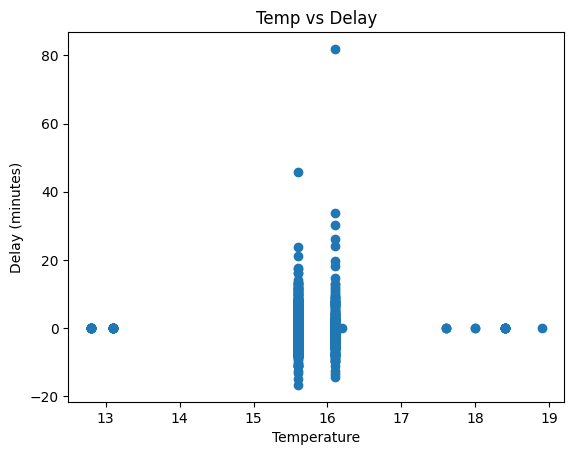

In [30]:
#sanity visualisation - verify data behaves normally
import matplotlib.pyplot as plt

plt.scatter(merged_df["temp"], merged_df["delay_minutes"])
plt.xlabel("Temperature")
plt.ylabel("Delay (minutes)")
plt.title("Temp vs Delay")
plt.show()

In [31]:
#final dataset shape check
print("Final dataset:", merged_df.shape)
merged_df.head()

Final dataset: (1288, 21)


,entity_id,trip_id,route_id,direction_id,start_time,start_date,timestamp,delay_seconds,is_deleted,delay_minutes,...,route_long_name,route_type,transport_mode,timestamp_dt,hour,temp,rhum,prcp,wspd,pres
0,521-93022-76500-1-23f81938,521-93022-76500-1-23f81938,MTID-241,1,21:15:00,20260430,1777414947,0,False,0.0,...,MTID,4.0,Ferry,2026-04-29 10:22:27,2026-04-29 10:00:00,16.2,88,0.0,5.8,1025.0
1,902-98011-82800-1-cdd3d9f0,902-98011-82800-1-cdd3d9f0,MTIA-209,0,23:00:00,20260430,1777482603,0,False,0.0,...,MTIA,4.0,Ferry,2026-04-30 05:10:03,2026-04-30 05:00:00,13.1,96,0.0,5.3,1025.1
2,902-98011-88200-1-cdd3d9f0,902-98011-88200-1-cdd3d9f0,MTIA-209,0,24:30:00,20260430,1777482612,0,False,0.0,...,MTIA,4.0,Ferry,2026-04-30 05:10:12,2026-04-30 05:00:00,13.1,96,0.0,5.3,1025.1
3,248-840018-70020-2-6155400-1931d669,248-840018-70020-2-6155400-1931d669,ONE-201,1,19:27:00,20260430,1777535095,-12,False,-0.2,...,ONE,2.0,Train,2026-04-30 19:44:55,2026-04-30 19:00:00,16.1,75,0.0,10.9,1028.6
4,248-840042-80820-2-6167400-d9ff341c,248-840042-80820-2-6167400-d9ff341c,ONE-201,1,22:27:00,20260430,1777484461,0,False,0.0,...,ONE,2.0,Train,2026-04-30 05:41:01,2026-04-30 05:00:00,13.1,96,0.0,5.3,1025.1


In [32]:
#save temporary merged dataset 
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
OUTPUT_PATH = PROJECT_ROOT / "data" / "interim" / "gtfs_weather_integrated_sample.csv"

merged_df.to_csv(OUTPUT_PATH, index=False)

print("Saved integrated dataset to:", OUTPUT_PATH)
print("Rows, columns:", merged_df.shape)

Saved integrated dataset to: d:\Yoobee\Term 3\Capstone\ai-dss-auckland-public-transport\data\interim\gtfs_weather_integrated_sample.csv
Rows, columns: (1288, 21)
